<a href="https://colab.research.google.com/github/nick1982ad/thethis_lib/blob/main/talks/2022_GreHack/Scapy%20in%200x30%20minutes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install scapy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 15.6 MB/s eta 0:00:00


In [ ]:
!apt install tcpdump

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libpcap0.8
Suggested packages:
  apparmor
The following NEW packages will be installed:
  libpcap0.8 tcpdump
0 upgraded, 2 newly installed, 0 to remove and 2 not upgraded.
Need to get 647 kB of archives.
After this operation, 1,773 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libpcap0.8 amd64 1.10.1-4ubuntu1.22.04.1 [145 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 tcpdump amd64 4.99.1-3ubuntu0.2 [501 kB]
Fetched 647 kB in 1s (458 kB/s)
Selecting previously unselected package libpcap0.8:amd64.
(Reading database ... 117540 files and directories currently installed.)
Preparing to unpack .../libpcap0.8_1.10.1-4ubuntu1.22.04.1_amd64.deb ...
Unpacking libpcap0.8:amd64 (1.10.1-4ubuntu1.22.04.1) ...
Selecting previously unselected package tcpdump.
Preparing to 

In [3]:
from scapy.all import *

# Today's Tutorial?

I will escort you in the discovery of most Scapy features:


- packets manipulation
- interacting with the network
- visualization
- using Scapy as a Python module
- implementing a new protocol
- answering machines
- IPv6 reconnaissance
- X.509 certificates manipulation
- TLS tricks
- advanced features: automaton, pipes

# Packets Manipulation

- packets are objects
- the `/` operator is used to stack packets

---

In [ ]:
packet = IP() / TCP()
Ether() / packet

<Ether  type=IPv4 |<IP  frag=0 proto=6 |<TCP  |>>>

- the `ls()` function list packets fields

---

```
>>> ls(IP, verbose=True)
version    : BitField (4 bits)                   = (4)
ihl        : BitField (4 bits)                   = (None)
tos        : XByteField                          = (0)
len        : ShortField                          = (None)
id         : ShortField                          = (1)
flags      : FlagsField (3 bits)                 = (0)
               MF, DF, evil
frag       : BitField (13 bits)                  = (0)
ttl        : ByteField                           = (64)
proto      : ByteEnumField                       = (0)
chksum     : XShortField                         = (None)
src        : SourceIPField (Emph)                = (None)
dst        : DestIPField (Emph)                  = (None)
options    : PacketListField                     = ([])
```

In [ ]:
ls(IP, verbose=True)

version    : BitField  (4 bits)                  = ('4')
ihl        : BitField  (4 bits)                  = ('None')
tos        : XByteField                          = ('0')
len        : ShortField                          = ('None')
id         : ShortField                          = ('1')
flags      : FlagsField                          = ('<Flag 0 ()>')
               MF, DF, evil
frag       : BitField  (13 bits)                 = ('0')
ttl        : ByteField                           = ('64')
proto      : ByteEnumField                       = ('0')
chksum     : XShortField                         = ('None')
src        : SourceIPField                       = ('None')
dst        : DestIPField                         = ('None')
options    : PacketListField                     = ('[]')


- Scapy selects the correct source IPv4 address, MAC addresses, ...

---

In [ ]:
p = Ether() / IP(dst="www.secdev.org") / TCP(flags="F")
p.summary()

'Ether / IP / TCP 172.28.0.12:20 > Net("www.secdev.org/32"):80 F'

- all fields can be easily accessed

---

In [ ]:
print(p.dst)      # first layer with a dst field, i.e. Ether
print(p[IP].src)  # explicit access to the IP layer src field

# sprintf() supports Scapy own formats strings
print(p.sprintf("%Ether.src% > %Ether.dst%\n%IP.src% > %IP.dst%"))

None
172.28.0.12
02:42:ac:1c:00:0c > None
172.28.0.12 > Net("www.secdev.org/32")


- a field can store many values

---

In [ ]:
[p for p in IP(ttl=(1,5)) / ICMP()]  # a sequence of values from 1 to 5

[<IP  frag=0 ttl=1 proto=1 |<ICMP  |>>,
 <IP  frag=0 ttl=2 proto=1 |<ICMP  |>>,
 <IP  frag=0 ttl=3 proto=1 |<ICMP  |>>,
 <IP  frag=0 ttl=4 proto=1 |<ICMP  |>>,
 <IP  frag=0 ttl=5 proto=1 |<ICMP  |>>]

In [ ]:
[p for p in IP() / TCP(dport=[22, 80, 443])]  # specific values

[<IP  frag=0 proto=6 |<TCP  dport=22 |>>,
 <IP  frag=0 proto=6 |<TCP  dport=80 |>>,
 <IP  frag=0 proto=6 |<TCP  dport=443 |>>]

# Interacting with the network

- the `sr1()` function sends a packet and returns a reply
- Scapy can match queries and answers
    
---

In [ ]:
p = sr1(IP(dst="8.8.8.8") / UDP() / DNS())
p[DNS].an


Received 2 packets, got 1 answers, remaining 0 packets


[<DNSRR  rrname=b'www.example.com.' type=A cacheflush=0 rclass=IN ttl=300 rdata=104.18.27.120 |>,
 <DNSRR  rrname=b'www.example.com.' type=A cacheflush=0 rclass=IN ttl=300 rdata=104.18.26.120 |>]

- the `srp()` function sends a list of frames and returns two variables:
    1. `r` a list of queries and matched answers
    2. `u` a list of unanswered packets

---

- a list of packets can be written to and read from a `PCAP` file

---

In [4]:
pcap_p = rdpcap("/content/drive/MyDrive/DataAnalysis/http_espn_fail.pcapng")
pcap_p[0]

<Ether  dst=c0:c1:c0:17:8c:e8 src=78:31:c1:cb:b2:56 type=IPv4 |<IP  version=4 ihl=5 tos=0x0 len=58 id=9480 flags= frag=0 ttl=64 proto=17 chksum=0x92fe src=172.16.16.154 dst=4.2.2.1 |<UDP  sport=57434 dport=53 len=38 chksum=0x791f |<DNS  id=45323 qr=0 opcode=QUERY aa=0 tc=0 rd=1 ra=0 z=0 ad=0 cd=0 rcode=ok qdcount=1 ancount=0 nscount=0 arcount=0 qd=[<DNSQR  qname=b'www.espn.com.' qtype=A unicastresponse=0 qclass=IN |>] |>>>>

- the `command()` method gives the string that will build the *same* object

---

In [ ]:
pcap_p[0].command()

"Ether(src='b8:ca:3a:72:b0:8b', dst='ac:16:2d:9c:3c:ad', type=2048)/IP(frag=0, src='192.168.46.10', proto=17, tos=0, dst='8.8.8.8', chksum=46829, len=61, options=[], version=4, flags=0, ihl=5, ttl=5, id=1)/UDP(dport=53, sport=53, len=41, chksum=46611)/DNS(aa=0, qr=0, an=None, ad=0, nscount=0, qdcount=1, ns=None, tc=0, rd=1, arcount=0, length=None, ar=None, opcode=0, ra=0, cd=0, z=0, rcode=0, id=0, ancount=0, qd=DNSQR(qclass=1, qtype=1, qname='www.example.com.'))"

- the `sniff()` function captures packets

---

In [ ]:
s = sniff(count=2)
s

<Sniffed: TCP:2 UDP:0 ICMP:0 Other:0>

In [ ]:
sniff(count=2, prn=lambda p: p.summary())

Ether / IP / TCP 172.28.0.1:41922 > 172.28.0.12:8080 S
Ether / IP / TCP 172.28.0.1:41934 > 172.28.0.12:8080 S


<Sniffed: TCP:2 UDP:0 ICMP:0 Other:0>

- the `lsc()` function lists available commands

---

```
>>> lsc()
IPID_count          : Identify IP id values classes in a list of packets
arpcachepoison      : Poison target's cache with (your MAC,victim's IP) couple
arping              : Send ARP who-has requests to determine which hosts are up
bind_layers         : Bind 2 layers on some specific fields' values
bridge_and_sniff    : Forward traffic between interfaces if1 and if2, sniff and return the
chexdump            :  Build a per byte hexadecimal representation
computeNIGroupAddr  : Compute the NI group Address. Can take a FQDN as input parameter
corrupt_bits        : Flip a given percentage or number of bits from a string
corrupt_bytes       : Corrupt a given percentage or number of bytes from a string
defrag              : defrag(plist) -> ([not fragmented], [defragmented],
defragment          : defrag(plist) -> plist defragmented as much as possible
dhcp_request        : --
[..]
```

- the `help()` function describes commands behaviors and arguments

---

```
>>> help(traceroute)
Help on function traceroute in module scapy.layers.inet:

traceroute(target, dport=80, minttl=1, maxttl=30, sport=<RandShort>, l4=None, filter=None, timeout=2, verbose=None, **kargs)
    Instant TCP traceroute
    traceroute(target, [maxttl=30,] [dport=80,] [sport=80,] [verbose=conf.verb]) -> None
```

# Visualization

- the `str()` function builds a packet, as sent on the network

In [ ]:
pkt = IP() / UDP() / DNS(qd=DNSQR())
repr(str(pkt))

'"IP / UDP / DNS Qry b\'www.example.com.\'"'

This representation being complicated, Scapy can:
   -  do a `hexdump` of the content

In [ ]:
hexdump(pkt)

0000  45 00 00 3D 00 01 00 00 40 11 7C AD 7F 00 00 01  E..=....@.|.....
0010  7F 00 00 01 00 35 00 35 00 29 B6 D3 00 00 01 00  .....5.5.)......
0020  00 01 00 00 00 00 00 00 03 77 77 77 07 65 78 61  .........www.exa
0030  6D 70 6C 65 03 63 6F 6D 00 00 01 00 01           mple.com.....


  - dump fields content layer by layer

In [ ]:
pkt.show()

###[ IP ]### 
  version   = 4
  ihl       = None
  tos       = 0x0
  len       = None
  id        = 1
  flags     = 
  frag      = 0
  ttl       = 64
  proto     = udp
  chksum    = None
  src       = 127.0.0.1
  dst       = 127.0.0.1
  \options   \
###[ UDP ]### 
     sport     = domain
     dport     = domain
     len       = None
     chksum    = None
###[ DNS ]### 
        id        = 0
        qr        = 0
        opcode    = QUERY
        aa        = 0
        tc        = 0
        rd        = 1
        ra        = 0
        z         = 0
        ad        = 0
        cd        = 0
        rcode     = ok
        qdcount   = 1
        ancount   = 0
        nscount   = 0
        arcount   = 0
        \qd        \
         |###[ DNS Question Record ]### 
         |  qname     = 'www.example.com'
         |  qtype     = A
         |  qclass    = IN
        an        = None
        ns        = None
        ar        = None



  - display a pretty representation

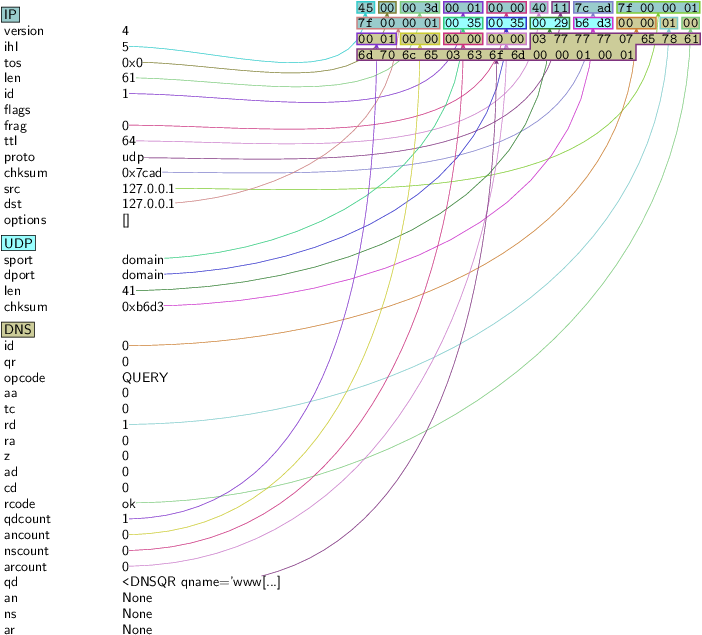

In [ ]:
pkt.canvas_dump()

In [ ]:
ans, unans = traceroute('www.secdev.org', maxttl=15)


Received 11 packets, got 11 answers, remaining 4 packets
   217.25.178.5:tcp80 
1  172.28.0.1      11 
2  192.178.254.91  11 
3  192.178.105.140 11 
7  198.32.118.57   11 
9  184.104.196.231 11 
10 184.104.189.18  11 
11 184.104.207.166 11 
12 217.25.179.111  11 
13 217.25.178.5    SA 
14 217.25.178.5    SA 
15 217.25.178.5    SA 


Different methods can be used to display the results, like `world_trace()` that uses the GeoIP module from [MaxMind](https://www.maxmind.com/)

---

## Scapy as a Python module

Scapy can be used to build your own tools like `ping6.py`:

---

In [ ]:
from scapy.all import *
import argparse

parser = argparse.ArgumentParser(description="A simple ping6")
parser.add_argument("ipv6_address", help="An IPv6 address")
args = parser.parse_args()

print sr1(IPv6(dst=args.ipv6_address) / ICMPv6EchoRequest(), verbose=0).summary()

```shell
sudo python ping6.py www.kame.net
IPv6 / ICMPv6 Echo Reply (id: 0x0 seq: 0x0)
```

## Answering Machines

Scapy can wait for a query, then send an answer with the `AnsweringMachine` object.

Two methods are mandatory:
1. `is_request()`: returns `True` if the packet is the expected query
2. `make_reply()`: returns the packet that will be sent by Scapy


Note: in the following example, the Wi-Fi interface must be put in *monitor* mode

In [ ]:
# Specify the Wi-Fi interface
conf.iface = "mon0"

# Create the Answering Machine
class ProbeRequest_am(AnsweringMachine):
  function_name = "pram"

  mac = "00:11:22:33:44:55"

  def is_request(self, pkt):
    return Dot11ProbeReq in pkt

  def make_reply(self, req):

    rep = RadioTap()
    # Note: depending on your Wi-Fi card, you might need something else than RadioTap()
    rep /= Dot11(addr1=req.addr2, addr2=self.mac, addr3=self.mac, ID=RandShort(), SC=RandShort())
    rep /= Dot11ProbeResp(cap="ESS", timestamp=time.time())
    rep /= Dot11Elt(ID="SSID",info="Scapy !")
    rep /= Dot11Elt(ID="Rates",info='\x82\x84\x0b\x16\x96')
    rep /= Dot11Elt(ID="DSset",info=chr(10))

    return rep

# Start the answering machine
#ProbeRequest_am()()  # uncomment to test

![](https://github.com/guedou/guedou.github.io/blob/master/talks/2022_GreHack/images/scapy_am.png?raw=1)

# X.509 Certificates Manipulation

- Scapy can easily parse certificates, and display their contents

---

In [5]:
load_layer("tls")
cert_github = Cert(open("/content/drive/MyDrive/DataAnalysis/github.pem").read())  # assuming you d/l the certificate
cert_github

[X.509 Cert. Subject:/CN=github.com, Issuer:/C=GB/O=Sectigo Limited/CN=Sectigo Public Server Authentication CA DV E36]

- several useful methods help exploring them

---

In [ ]:
print(cert_github.isSelfSigned())  # check if it is self signed
print(cert_github.subject)  # display the subject
print(cert_github.remainingDays()) # compute the number of days until expiration

False
{'commonName': 'github.com'}
85.02425925925925


# TLS tricks

- sniff TLS traffic

---

In [6]:
load_layer("tls")
#s = sniff(filter="port 443", count=10)  # sniff packets on port 443
s = rdpcap("/content/drive/MyDrive/DataAnalysis/tls.pcapng")
ch_list = [p for p in s if TLSClientHello in p]  # filter Client Hello messages
ch_list[0][TLSClientHello].show()  # display the first message

###[ TLS Handshake - Client Hello ]###
  msgtype   = client_hello
  msglen    = 774
  version   = TLS 1.2
  gmt_unix_time= Sun, 28 May 2102 20:12:20  (4178290340)
  random_bytes= db608a0658107674bc1b5515c6d65db4701f4db59e9ac8a4b0017930
  sidlen    = 32
  sid       = b')\xf0\x0e\x95\x0e \x86\xac>\xca\x97\xbdU\x8dn\x05Mt\xe0\x0c\x9b,;Ie\x19\xb3\x12\x1f\xa8\xe3\xf6'
  cipherslen= 40
  ciphers   = [TLS_AES_256_GCM_SHA384, TLS_AES_128_GCM_SHA256, TLS_ECDHE_ECDSA_WITH_AES_256_GCM_SHA384, TLS_ECDHE_ECDSA_WITH_AES_128_GCM_SHA256, TLS_ECDHE_RSA_WITH_AES_256_GCM_SHA384, TLS_ECDHE_RSA_WITH_AES_128_GCM_SHA256, TLS_ECDHE_ECDSA_WITH_AES_256_CBC_SHA384, TLS_ECDHE_ECDSA_WITH_AES_128_CBC_SHA256, TLS_ECDHE_RSA_WITH_AES_256_CBC_SHA384, TLS_ECDHE_RSA_WITH_AES_128_CBC_SHA256, TLS_ECDHE_ECDSA_WITH_AES_256_CBC_SHA, TLS_ECDHE_ECDSA_WITH_AES_128_CBC_SHA, TLS_ECDHE_RSA_WITH_AES_256_CBC_SHA, TLS_ECDHE_RSA_WITH_AES_128_CBC_SHA, TLS_RSA_WITH_AES_256_GCM_SHA384, TLS_RSA_WITH_AES_128_GCM_SHA256, TLS_RSA_WITH_AES_256